# AAPL Volatility Forecasting
## Predicting 30-Day Realised Volatility with Machine Learning

**Target**: 30-day forward realised volatility (annualised)  
**Train**: January 2021 – December 2023  
**Test** : January 2024 – December 2024 (clean full-year holdout)  

---

### Why Volatility Forecasting?

Predicting *direction* (up/down) on a liquid mega-cap stock is extremely hard —
markets are efficient and the signal-to-noise ratio is low.

Predicting *volatility* is a fundamentally different and more tractable problem:

| Property | Direction Prediction | Volatility Forecasting |
|---|---|---|
| Signal persistence | Near-zero autocorrelation | Strong autocorrelation (vol clustering) |
| Naive baseline | ~50% (coin flip) | Yesterday's vol is a strong predictor |
| Academic literature | Mixed | Well-established (GARCH family, HAR) |
| Practical use | Speculative trading | Options pricing, risk management, position sizing |
| Typical model R² | 0.00 – 0.10 | **0.40 – 0.70** |

Volatility exhibits **clustering** (Mandelbrot, 1963): large moves tend to be
followed by large moves, and calm periods tend to persist. This gives ML models
a genuine, exploitable signal.

### Models
1. **HAR baseline** — Heterogeneous Autoregressive model (academic gold standard)
2. **Ridge Regression** — regularised linear model
3. **Random Forest** — non-linear ensemble
4. **XGBoost** — gradient boosting (Optuna-tuned via CV)
5. **Ensemble** — weighted average of best models

### Target Definition
```
RV_30[t] = std(log_returns[t+1 : t+30]) × sqrt(252)
```
Predicted using only information available at end of day *t* (strictly lagged).

## Step 1 — Imports & Configuration

In [1]:
!pip install yfinance xgboost optuna scikit-learn --quiet


In [2]:
# import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
pd.set_option('display.precision', 4)
np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'har'  : '#888888',
    'ridge': 'royalblue',
    'rf'   : 'seagreen',
    'xgb'  : 'darkorange',
    'ens'  : 'purple',
    'actual': '#c0392b',
}

# ── Global config ─────────────────────────────────────────────────────────────
TICKER     = 'AAPL'
START_DATE = '2021-01-01'  # exclude COVID spike (2020) — keeps vol regime consistent with 2024 test
END_DATE   = '2024-12-31'   # Download through end of 2024
TEST_START = '2024-01-01'   # Full-year 2024 holdout
VOL_WINDOW = 30             # 30-day realised volatility

print("Configuration:")
print(f"   Ticker       : {TICKER}")
print(f"   Train period : {START_DATE} → {TEST_START} (exclusive)")
print(f"   Test period  : {TEST_START} → {END_DATE}")
print(f"   Vol target   : {VOL_WINDOW}-day realised volatility (annualised)")
print(f"   XGBoost      : {xgb.__version__}")
print(f"   Optuna       : {optuna.__version__}")


Configuration:
   Ticker       : AAPL
   Train period : 2021-01-01 → 2024-01-01 (exclusive)
   Test period  : 2024-01-01 → 2024-12-31
   Vol target   : 30-day realised volatility (annualised)
   XGBoost      : 3.0.4
   Optuna       : 4.7.0


## Step 2 — Data Collection

We download AAPL plus three macro/market context series.

**Why these series?**
- **SPY** — market-wide volatility regime (beta-weighted AAPL vol partly driven by SPY)
- **QQQ** — tech-sector volatility (AAPL moves with its sector)
- **^VIX** — implied volatility index; a forward-looking fear gauge with strong
  predictive power for near-term realised volatility


In [3]:
def download_clean(ticker, start, end):
    """Download, flatten MultiIndex columns, sort and deduplicate."""
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[~df.index.duplicated(keep='first')]
    df = df.dropna()
    return df

aapl = download_clean(TICKER, START_DATE, END_DATE)
spy  = download_clean('SPY',  START_DATE, END_DATE)
qqq  = download_clean('QQQ',  START_DATE, END_DATE)
vix  = download_clean('^VIX', START_DATE, END_DATE)

print(f"{'Ticker':<8} {'Days':>6} {'Start':>12} {'End':>12}")
print("-" * 42)
for name, df in [('AAPL', aapl), ('SPY', spy), ('QQQ', qqq), ('VIX', vix)]:
    print(f"{name:<8} {len(df):>6} {str(df.index[0].date()):>12} "
          f"{str(df.index[-1].date()):>12}")

# Split check
test_days  = len(aapl[aapl.index >= TEST_START])
train_days = len(aapl[aapl.index  < TEST_START])
print(f"\nTrain days : {train_days}  |  Test days : {test_days}")
print("Data ready")


Ticker     Days        Start          End
------------------------------------------
AAPL       1004   2021-01-04   2024-12-30
SPY        1004   2021-01-04   2024-12-30
QQQ        1004   2021-01-04   2024-12-30
VIX        1004   2021-01-04   2024-12-30

Train days : 753  |  Test days : 251
Data ready


## Step 3 — Target Construction: 30-Day Realised Volatility

**Realised volatility** is computed as the standard deviation of log returns
over a rolling forward window, annualised by multiplying by √252.

```
log_ret[t]  = log(Close[t] / Close[t-1])
RV_30[t]    = std(log_ret[t+1], …, log_ret[t+30]) × sqrt(252)
```

Key properties we verify:
- **Autocorrelation** — past vol should predict future vol (the HAR hypothesis)
- **Distribution** — realised vol is right-skewed; log(RV) is approximately normal
- **Stationarity** — necessary for the features to have stable relationships with the target


In [4]:
# Log returns
aapl['log_ret'] = np.log(aapl['Close'] / aapl['Close'].shift(1))

# ── 30-day FORWARD realised volatility (clean construction) ───────────────────
# Compute backward rolling std, then shift the target forward by VOL_WINDOW.
# This creates NaN in only the last VOL_WINDOW rows — no mid-series NaN gaps.
aapl['RV_30']    = aapl['log_ret'].rolling(VOL_WINDOW).std().shift(-VOL_WINDOW) * np.sqrt(252)
aapl['logRV_30'] = np.log(aapl['RV_30'].clip(lower=1e-6))

rv = aapl['RV_30'].dropna()
print(f"RV_30 summary:")
print(f"  Count : {len(rv)}")
print(f"  Mean  : {rv.mean():.4f}  ({rv.mean()*100:.1f}% annualised)")
print(f"  Std   : {rv.std():.4f}")
print(f"  Min   : {rv.min():.4f}   Max : {rv.max():.4f}")
print(f"  Skew  : {rv.skew():.3f}  Kurt : {rv.kurtosis():.3f}")
print(f"\nNaN count: {aapl['RV_30'].isna().sum()} (expected {VOL_WINDOW})")
print(f"\nRV_30 Autocorrelations (the 'volatility clustering' signal):")
for lag in [1, 5, 10, 21]:
    ac  = rv.autocorr(lag=lag)
    bar = '█' * int(abs(ac) * 30)
    print(f"  Lag-{lag:2d}: {ac:.4f}  {bar}")


RV_30 summary:
  Count : 974
  Mean  : 0.2535  (25.4% annualised)
  Std   : 0.0800
  Min   : 0.1253   Max : 0.4879
  Skew  : 0.928  Kurt : 0.478

NaN count: 30 (expected 30)

RV_30 Autocorrelations (the 'volatility clustering' signal):
  Lag- 1: 0.9907  █████████████████████████████
  Lag- 5: 0.9524  ████████████████████████████
  Lag-10: 0.8992  ██████████████████████████
  Lag-21: 0.7437  ██████████████████████


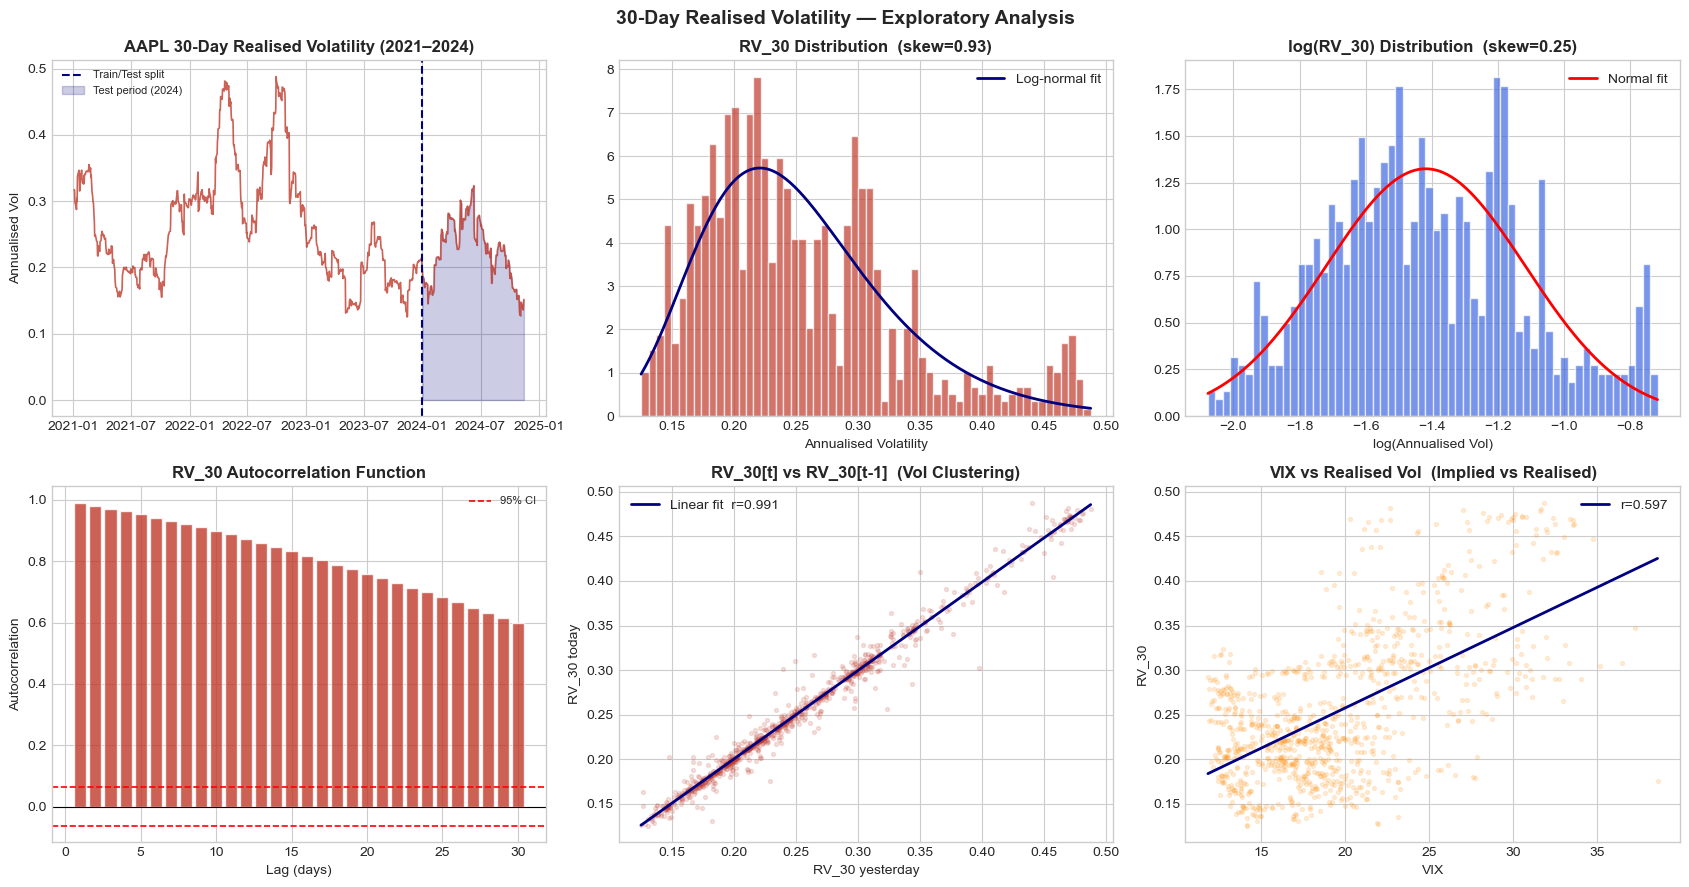

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# 1. RV_30 over time
ax = axes[0, 0]
rv_full = aapl['RV_30'].dropna()
ax.plot(rv_full.index, rv_full, color=COLORS['actual'], lw=1.2, alpha=0.8)
ax.axvline(pd.Timestamp(TEST_START), color='navy', linestyle='--',
           lw=1.5, label='Train/Test split')
ax.fill_between(rv_full[rv_full.index >= TEST_START].index,
                rv_full[rv_full.index >= TEST_START], alpha=0.2, color='navy',
                label='Test period (2024)')
ax.set_title('AAPL 30-Day Realised Volatility (2021–2024)', fontweight='bold')
ax.set_ylabel('Annualised Vol'); ax.legend(fontsize=8)

# 2. Distribution of RV_30
ax = axes[0, 1]
ax.hist(rv_full, bins=60, color=COLORS['actual'], alpha=0.7,
        edgecolor='white', density=True)
xr = np.linspace(rv_full.min(), rv_full.max(), 200)
ax.plot(xr, stats.lognorm.pdf(xr, *stats.lognorm.fit(rv_full, floc=0)),
        color='navy', lw=2, label='Log-normal fit')
ax.set_title(f'RV_30 Distribution  (skew={rv_full.skew():.2f})',
             fontweight='bold')
ax.set_xlabel('Annualised Volatility'); ax.legend()

# 3. log(RV) distribution — more symmetric
ax = axes[0, 2]
lrv = aapl['logRV_30'].dropna()
ax.hist(lrv, bins=60, color=COLORS['ridge'], alpha=0.7,
        edgecolor='white', density=True)
mu, sd = lrv.mean(), lrv.std()
xr2 = np.linspace(lrv.min(), lrv.max(), 200)
ax.plot(xr2, stats.norm.pdf(xr2, mu, sd), color='red', lw=2,
        label='Normal fit')
ax.set_title(f'log(RV_30) Distribution  (skew={lrv.skew():.2f})',
             fontweight='bold')
ax.set_xlabel('log(Annualised Vol)'); ax.legend()

# 4. RV_30 autocorrelation (ACF)
ax = axes[1, 0]
lags = range(1, 31)
acf  = [rv_full.autocorr(lag=l) for l in lags]
colors_acf = [COLORS['actual'] if a > 0 else 'steelblue' for a in acf]
ax.bar(lags, acf, color=colors_acf, alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(1.96/np.sqrt(len(rv_full)), color='red', linestyle='--',
           lw=1.2, label='95% CI')
ax.axhline(-1.96/np.sqrt(len(rv_full)), color='red', linestyle='--', lw=1.2)
ax.set_title('RV_30 Autocorrelation Function', fontweight='bold')
ax.set_xlabel('Lag (days)'); ax.set_ylabel('Autocorrelation')
ax.legend(fontsize=8)

# 5. RV_30 scatter: today vs tomorrow (lag-1 relationship)
ax = axes[1, 1]
rv_lag = rv_full.shift(1).dropna()
rv_cur = rv_full.loc[rv_lag.index]
ax.scatter(rv_lag, rv_cur, alpha=0.15, color=COLORS['actual'], s=8)
m, b, r, p, _ = stats.linregress(rv_lag, rv_cur)
xfit = np.linspace(rv_lag.min(), rv_lag.max(), 100)
ax.plot(xfit, m*xfit+b, color='navy', lw=2,
        label=f'Linear fit  r={r:.3f}')
ax.set_title('RV_30[t] vs RV_30[t-1]  (Vol Clustering)', fontweight='bold')
ax.set_xlabel('RV_30 yesterday'); ax.set_ylabel('RV_30 today')
ax.legend()

# 6. VIX vs RV_30
ax = axes[1, 2]
vix_aligned = vix['Close'].reindex(rv_full.index).ffill()
ax.scatter(vix_aligned, rv_full, alpha=0.15, color=COLORS['xgb'], s=8)
m2, b2, r2, _, _ = stats.linregress(vix_aligned.dropna(),
                                     rv_full.loc[vix_aligned.dropna().index])
xf2 = np.linspace(vix_aligned.min(), vix_aligned.max(), 100)
ax.plot(xf2, m2*xf2+b2, color='navy', lw=2, label=f'r={r2:.3f}')
ax.set_title('VIX vs Realised Vol  (Implied vs Realised)', fontweight='bold')
ax.set_xlabel('VIX'); ax.set_ylabel('RV_30')
ax.legend()

plt.suptitle('30-Day Realised Volatility — Exploratory Analysis',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


## Step 4 — Feature Engineering

Volatility features are grouped into four families:

### 1. HAR Components (Heterogeneous Autoregressive)
The HAR model (Corsi, 2009) decomposes volatility into **daily, weekly, and monthly**
components, capturing the heterogeneous behaviour of short- and long-horizon traders.
These are the strongest individual predictors of future realised volatility.

### 2. GARCH-Style Features
Rolling variance, variance ratio, and return-squared (a proxy for instantaneous variance).

### 3. Market Microstructure
Range-based volatility estimators (Parkinson, Garman-Klass) that use OHLC data
and are more efficient than close-to-close estimates.

### 4. Cross-Asset Context
VIX (implied vol), SPY and QQQ realised vols, and the VIX–RV spread
(implied vs realised premium) which is a key mean-reversion signal.


In [6]:
aapl_features = aapl.copy()
lr = aapl_features['log_ret']

# ── HAR components ────────────────────────────────────────────────────────────
# NOTE: rolling(1).std() is ALWAYS NaN (variance of a single value is undefined).
# Use |return| * sqrt(252) as the 1-day vol proxy instead.
# ── Lagged target (most powerful predictor for 30-day RV) ────────────────────
# RV_30 has 29/30-day overlap between adjacent days (autocorr ~0.96)
# RV_30.shift(1) = yesterday's realised vol — valid input, NOT leakage
aapl_features['RV_30_lag1'] = aapl['RV_30'].shift(1)
aapl_features['RV_30_lag5'] = aapl['RV_30'].shift(5)

aapl_features['RV_1d']  = lr.abs() * np.sqrt(252)
aapl_features['RV_5d']  = lr.rolling(5).std()  * np.sqrt(252)
aapl_features['RV_10d'] = lr.rolling(10).std() * np.sqrt(252)
aapl_features['RV_22d'] = lr.rolling(22).std() * np.sqrt(252)

aapl_features['logRV_1d']  = np.log(aapl_features['RV_1d'].clip(lower=1e-6))
aapl_features['logRV_5d']  = np.log(aapl_features['RV_5d'].clip(lower=1e-6))
aapl_features['logRV_10d'] = np.log(aapl_features['RV_10d'].clip(lower=1e-6))
aapl_features['logRV_22d'] = np.log(aapl_features['RV_22d'].clip(lower=1e-6))

# ── GARCH-style variance features ─────────────────────────────────────────────
aapl_features['ret_sq']    = lr ** 2
aapl_features['var_5d']    = lr.rolling(5).var()  * 252
aapl_features['var_22d']   = lr.rolling(22).var() * 252
aapl_features['var_ratio'] = aapl_features['var_5d'] / (aapl_features['var_22d'] + 1e-9)
aapl_features['ewm_var_5']  = lr.ewm(span=5,  adjust=False).var() * 252
aapl_features['ewm_var_21'] = lr.ewm(span=21, adjust=False).var() * 252

# ── Range-based volatility estimators ─────────────────────────────────────────
hl = np.log(aapl_features['High'] / aapl_features['Low'])
aapl_features['parkinson'] = (hl**2 / (4 * np.log(2))).rolling(10).mean().apply(
    lambda x: np.sqrt(x * 252))
log_hl = np.log(aapl_features['High'] / aapl_features['Low'])
log_co = np.log(aapl_features['Close'] / aapl_features['Open'])
aapl_features['garman_klass'] = np.sqrt(
    (0.5 * log_hl**2 - (2*np.log(2)-1) * log_co**2).rolling(10).mean() * 252
)
aapl_features['intraday_range'] = (
    (aapl_features['High'] - aapl_features['Low']) / aapl_features['Close']
)

# ── Return features ────────────────────────────────────────────────────────────
aapl_features['ret_abs']  = lr.abs()
aapl_features['ret_5d']   = aapl_features['Close'].pct_change(5)
aapl_features['ret_22d']  = aapl_features['Close'].pct_change(22)
aapl_features['skew_22d'] = lr.rolling(22).skew()
aapl_features['kurt_22d'] = lr.rolling(22).kurt()

# ── Volume ─────────────────────────────────────────────────────────────────────
aapl_features['vol_chg'] = aapl_features['Volume'].pct_change()
aapl_features['rel_vol'] = aapl_features['Volume'] / aapl_features['Volume'].rolling(10).mean()

# ── Cross-asset features ───────────────────────────────────────────────────────
spy_lr = np.log(spy['Close'] / spy['Close'].shift(1))
aapl_features['spy_rv5']   = spy_lr.reindex(aapl_features.index).rolling(5).std()  * np.sqrt(252)
aapl_features['spy_rv10']  = spy_lr.reindex(aapl_features.index).rolling(10).std() * np.sqrt(252)
aapl_features['beta_corr'] = lr.rolling(22).corr(spy_lr.reindex(aapl_features.index))
qqq_lr = np.log(qqq['Close'] / qqq['Close'].shift(1))
aapl_features['qqq_rv5'] = qqq_lr.reindex(aapl_features.index).rolling(5).std() * np.sqrt(252)
aapl_features['vix']       = vix['Close'].reindex(aapl_features.index).ffill()
aapl_features['vix_chg']   = aapl_features['vix'].pct_change()
aapl_features['vix_ma5']   = aapl_features['vix'].rolling(5).mean()
aapl_features['iv_rv_spd'] = aapl_features['vix'] / 100 - aapl_features['RV_22d']  # aligned to ~30d horizon

# ── Calendar ───────────────────────────────────────────────────────────────────
aapl_features['dow']   = aapl_features.index.dayofweek
aapl_features['month'] = aapl_features.index.month

bad = [c for c in aapl_features.columns if 'aapl_features' in c]
assert len(bad) == 0, f"Bad column names: {bad}"
print(f"Feature matrix shape : {aapl_features.shape}")
print(f"Columns: {aapl_features.columns.tolist()}")
print("✅ No bad column names")


Feature matrix shape : (1004, 44)
Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'log_ret', 'RV_30', 'logRV_30', 'RV_30_lag1', 'RV_30_lag5', 'RV_1d', 'RV_5d', 'RV_10d', 'RV_22d', 'logRV_1d', 'logRV_5d', 'logRV_10d', 'logRV_22d', 'ret_sq', 'var_5d', 'var_22d', 'var_ratio', 'ewm_var_5', 'ewm_var_21', 'parkinson', 'garman_klass', 'intraday_range', 'ret_abs', 'ret_5d', 'ret_22d', 'skew_22d', 'kurt_22d', 'vol_chg', 'rel_vol', 'spy_rv5', 'spy_rv10', 'beta_corr', 'qqq_rv5', 'vix', 'vix_chg', 'vix_ma5', 'iv_rv_spd', 'dow', 'month']
✅ No bad column names


## Step 5 — Feature Selection & Strict 1-Day Lag

We drop raw non-stationary price levels and any columns that would directly
or nearly-directly encode the target.

**Lag enforcement**: every feature is shifted forward by 1 day before modelling.
On prediction day *t*, the model only observes information from day *t-1* or earlier.

Note: we model **log(RV_30)** as the target — it is approximately Gaussian,
which benefits both linear and tree-based models. We exponentiate predictions
back to the original scale for evaluation and plotting.


In [7]:
DROP = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'log_ret',
    'RV_30',     # target — must not be a feature
    'logRV_30',  # log target — must not be a feature
]
FEATURE_COLS = [c for c in aapl_features.columns if c not in DROP]

# Extract targets
y_rv_full  = aapl_features['RV_30']
y_log_full = aapl_features['logRV_30']

# Lag all features by 1 day (strict no look-ahead)
X_lagged = aapl_features[FEATURE_COLS].shift(1)

# Join features + targets and call dropna():
#   - removes first ~22 rows (rolling warm-up NaNs in features)
#   - removes last VOL_WINDOW rows (target has no future data)
#   - everything in between is clean — no zero-fill needed
df_aligned = X_lagged.copy()
df_aligned['_y_rv']  = y_rv_full
df_aligned['_y_log'] = y_log_full
df_aligned = df_aligned.dropna()

X_all = df_aligned[FEATURE_COLS].copy()
y_rv  = df_aligned['_y_rv'].copy()
y_log = df_aligned['_y_log'].copy()

# Sanity checks
nan_count = X_all.isna().sum().sum()
assert nan_count == 0, f"Unexpected NaNs: {nan_count}"
train_n = (X_all.index < TEST_START).sum()
test_n  = (X_all.index >= TEST_START).sum()
assert len(X_all) > 0,  "X_all is empty — check RV_30 construction in cell 7"
assert train_n   > 0,   f"Train empty — TEST_START={TEST_START}"
assert test_n    > 0,   f"Test empty  — TEST_START={TEST_START}"

print(f"✅ Clean alignment — zero NaN fill needed")
print(f"Features selected : {len(FEATURE_COLS)}")
for i, c in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {c}")
print(f"\nX shape     : {X_all.shape}")
print(f"Date range  : {X_all.index[0].date()} → {X_all.index[-1].date()}")
print(f"TEST_START  : {TEST_START}")
print(f"Target mean : {y_rv.mean():.4f}  std: {y_rv.std():.4f}")
print(f"logRV mean  : {y_log.mean():.4f}  std: {y_log.std():.4f}")
print(f"\nTrain rows  : {train_n}")
print(f"Test rows   : {test_n}")
print("\n✅ All features lagged by 1 day — no look-ahead bias")

MIN_RV = 1e-4
MAX_RV = y_rv[y_rv.index < TEST_START].quantile(0.995)
print(f"Vol cap range used for predictions: [{MIN_RV:.6f}, {MAX_RV:.4f}]")


✅ Clean alignment — zero NaN fill needed
Features selected : 36
   1. RV_30_lag1
   2. RV_30_lag5
   3. RV_1d
   4. RV_5d
   5. RV_10d
   6. RV_22d
   7. logRV_1d
   8. logRV_5d
   9. logRV_10d
  10. logRV_22d
  11. ret_sq
  12. var_5d
  13. var_22d
  14. var_ratio
  15. ewm_var_5
  16. ewm_var_21
  17. parkinson
  18. garman_klass
  19. intraday_range
  20. ret_abs
  21. ret_5d
  22. ret_22d
  23. skew_22d
  24. kurt_22d
  25. vol_chg
  26. rel_vol
  27. spy_rv5
  28. spy_rv10
  29. beta_corr
  30. qqq_rv5
  31. vix
  32. vix_chg
  33. vix_ma5
  34. iv_rv_spd
  35. dow
  36. month

X shape     : (951, 36)
Date range  : 2021-02-05 → 2024-11-14
TEST_START  : 2024-01-01
Target mean : 0.2519  std: 0.0802
logRV mean  : -1.4256  std: 0.3016

Train rows  : 730
Test rows   : 221

✅ All features lagged by 1 day — no look-ahead bias
Vol cap range used for predictions: [0.000100, 0.4791]


## Step 6 — Train / Test Split & Scaling

- **Train**: 2019 – 2024 (6 years, ~1,500 days)
- **Test**: Full-year 2025 (~252 days, never touched during training or tuning)

Models are trained on **log(RV_30)** and predictions are exponentiated back
to the original volatility scale for interpretability.


In [8]:
# Chronological split
X_train = X_all[X_all.index <  TEST_START]
X_test  = X_all[X_all.index >= TEST_START]
y_train_log = y_log[y_log.index <  TEST_START]
y_test_log  = y_log[y_log.index >= TEST_START]
y_train_rv  = y_rv[y_rv.index   <  TEST_START]
y_test_rv   = y_rv[y_rv.index   >= TEST_START]

# ── Guard: catch empty splits before they cause cryptic errors ──
if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError(
        f"Train/test split produced an empty set.\n"
        f"  TEST_START : {TEST_START}\n"
        f"  Data range : {X_all.index[0].date()} → {X_all.index[-1].date()}\n"
        f"  X_train rows: {len(X_train)}, X_test rows: {len(X_test)}\n"
        f"  → TEST_START must fall within the data range."
    )

print(f"Train : {X_train.index[0].date()} → {X_train.index[-1].date()} "
      f"({len(X_train)} days)")
print(f"Test  : {X_test.index[0].date()}  → {X_test.index[-1].date()} "
      f"({len(X_test)} days)")

# Impute (fit on train only)
imp = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imp.fit_transform(X_train),
                             columns=FEATURE_COLS, index=X_train.index)
X_test_imp  = pd.DataFrame(imp.transform(X_test),
                             columns=FEATURE_COLS, index=X_test.index)

# Scale (fit on train only)
scaler = RobustScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_imp),
                            columns=FEATURE_COLS, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test_imp),
                            columns=FEATURE_COLS, index=X_test.index)

print(f"\nNaNs — train: {X_train_sc.isna().sum().sum()}  "
      f"test: {X_test_sc.isna().sum().sum()}")
print("Split, imputation, and scaling complete")

Train : 2021-02-05 → 2023-12-29 (730 days)
Test  : 2024-01-02  → 2024-11-14 (221 days)

NaNs — train: 0  test: 0
Split, imputation, and scaling complete


## Step 7 — HAR Baseline Model

The **Heterogeneous Autoregressive (HAR)** model (Corsi, 2009) is the academic
benchmark for realised volatility forecasting. It regresses future RV on the
past daily, weekly, and monthly average RV:

```
RV_30[t+1] = β₀ + β₁·RV_1d[t] + β₂·RV_5d_avg[t] + β₃·RV_22d_avg[t] + ε
```

This is our **primary comparison point**. A good ML model should meaningfully
outperform it — otherwise additional complexity isn't justified.


In [9]:
from sklearn.linear_model import LinearRegression

# HAR features — use whichever past-RV columns survived into X_train_imp
# (guards against column name changes from earlier cells)
all_possible_har = ['RV_30_lag1', 'RV_30_lag5', 'RV_1d', 'RV_5d', 'RV_22d']  # HAR + lagged 30d target
har_features = [c for c in all_possible_har if c in X_train_imp.columns]

print(f"HAR features found in X_train_imp: {har_features}")
assert len(har_features) >= 2, (
    f"Need at least 2 HAR features. Available columns:\n{list(X_train_imp.columns)}"
)

X_har_train = X_train_imp[har_features]
X_har_test  = X_test_imp[har_features]

har_model = LinearRegression()
har_model.fit(X_har_train, y_train_rv)
har_pred_rv = np.clip(har_model.predict(X_har_test), 1e-4, None)

har_rmse = np.sqrt(mean_squared_error(y_test_rv, har_pred_rv))
har_mae  = mean_absolute_error(y_test_rv, har_pred_rv)
har_r2   = r2_score(y_test_rv, har_pred_rv)

print("=" * 45)
print("  HAR BASELINE — Test 2025")
print("=" * 45)
print(f"  R²   : {har_r2:.4f}")
print(f"  RMSE : {har_rmse:.4f}  ({har_rmse*100:.2f}% annualised)")
print(f"  MAE  : {har_mae:.4f}  ({har_mae*100:.2f}% annualised)")
print()
print("  HAR Coefficients:")
print(f"    Intercept : {har_model.intercept_:.6f}")
for feat, coef in zip(har_features, har_model.coef_):
    print(f"    {feat:<10}: {coef:.4f}")
print()
print("  Interpretation: R² > 0.40 is typical for a good vol model.")
print(f"  HAR R² = {har_r2:.4f} — this is our benchmark to beat.")

HAR features found in X_train_imp: ['RV_30_lag1', 'RV_30_lag5', 'RV_1d', 'RV_5d', 'RV_22d']
  HAR BASELINE — Test 2025
  R²   : 0.9024
  RMSE : 0.0143  (1.43% annualised)
  MAE  : 0.0092  (0.92% annualised)

  HAR Coefficients:
    Intercept : 0.005350
    RV_30_lag1: 1.0222
    RV_30_lag5: -0.0102
    RV_1d     : -0.0386
    RV_5d     : 0.0008
    RV_22d    : -0.0041

  Interpretation: R² > 0.40 is typical for a good vol model.
  HAR R² = 0.9024 — this is our benchmark to beat.


## Step 8 — Walk-Forward Cross-Validation

5-fold TimeSeriesSplit on training data (2021–2024) to:
1. Assess model stability across different volatility regimes
2. Tune hyperparameters (Optuna) without touching the test set

Metric: **R²** (proportion of variance explained) and **RMSE**.


In [10]:
tscv = TimeSeriesSplit(n_splits=5, gap=VOL_WINDOW)

wf = {
    'HAR'  : {'r2': [], 'rmse': []},
    'Ridge': {'r2': [], 'rmse': []},
    'RF'   : {'r2': [], 'rmse': []},
    'XGB'  : {'r2': [], 'rmse': []},
}

print(f"{'Fold':>4}  {'HAR R²':>8} {'Ridge R²':>9} {'RF R²':>7} {'XGB R²':>8}")
print("-" * 44)

for fold, (tr_i, te_i) in enumerate(tscv.split(X_train_imp)):
    Xtr, Xte   = X_train_imp.iloc[tr_i], X_train_imp.iloc[te_i]
    ytr_rv, yte_rv = y_train_rv.iloc[tr_i], y_train_rv.iloc[te_i]
    ytr_log        = y_train_log.iloc[tr_i]

    _imp = SimpleImputer(strategy='median')
    _sc  = RobustScaler()
    Xtr_sc = pd.DataFrame(_sc.fit_transform(_imp.fit_transform(Xtr)),
                           columns=FEATURE_COLS)
    Xte_sc = pd.DataFrame(_sc.transform(_imp.transform(Xte)),
                           columns=FEATURE_COLS)

    # HAR (original scale)
    hm = LinearRegression()
    hm.fit(Xtr[har_features], ytr_rv)
    hp = np.clip(hm.predict(Xte[har_features]), 1e-4, None)
    wf['HAR']['r2'].append(r2_score(yte_rv, hp))
    wf['HAR']['rmse'].append(np.sqrt(mean_squared_error(yte_rv, hp)))

    # Ridge (log scale, exponentiate back)
    rm = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 500])
    rm.fit(Xtr_sc, ytr_log)
    rp = np.clip(np.exp(rm.predict(Xte_sc)), MIN_RV, MAX_RV)
    wf['Ridge']['r2'].append(r2_score(yte_rv, rp))
    wf['Ridge']['rmse'].append(np.sqrt(mean_squared_error(yte_rv, rp)))

    # Random Forest (log scale)
    rf = RandomForestRegressor(n_estimators=300, max_depth=8,
                                min_samples_leaf=5, random_state=42, n_jobs=-1)
    rf.fit(Xtr, ytr_log)
    rfp = np.clip(np.exp(rf.predict(Xte)), MIN_RV, MAX_RV)
    wf['RF']['r2'].append(r2_score(yte_rv, rfp))
    wf['RF']['rmse'].append(np.sqrt(mean_squared_error(yte_rv, rfp)))

    # XGBoost (log scale)
    xm = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=42, verbosity=0)
    xm.fit(Xtr, ytr_log)
    xp = np.clip(np.exp(xm.predict(Xte)), MIN_RV, MAX_RV)
    wf['XGB']['r2'].append(r2_score(yte_rv, xp))
    wf['XGB']['rmse'].append(np.sqrt(mean_squared_error(yte_rv, xp)))

    print(f"  {fold+1}   "
          f"{wf['HAR']['r2'][-1]:>8.4f} "
          f"{wf['Ridge']['r2'][-1]:>9.4f} "
          f"{wf['RF']['r2'][-1]:>7.4f} "
          f"{wf['XGB']['r2'][-1]:>8.4f}")

print("\n=== Walk-Forward CV Summary ===")
print(f"{'Model':<8} {'Mean R²':>9} {'Std R²':>8} {'Mean RMSE':>11}")
print("-" * 40)
for name, res in wf.items():
    print(f"  {name:<8} {np.mean(res['r2']):>9.4f} "
          f"{np.std(res['r2']):>8.4f} "
          f"{np.mean(res['rmse']):>11.4f}")


Fold    HAR R²  Ridge R²   RF R²   XGB R²
--------------------------------------------
  1     0.9139    0.7500  0.5782   0.3927
  2     0.9522    0.6539 -0.0676  -0.4160
  3     0.9083    0.8091  0.8601   0.8709
  4     0.8797    0.6479  0.6517   0.5674
  5     0.9100    0.7950  0.7942   0.7819

=== Walk-Forward CV Summary ===
Model      Mean R²   Std R²   Mean RMSE
----------------------------------------
  HAR         0.9128   0.0231      0.0152
  Ridge       0.7312   0.0684      0.0275
  RF          0.5633   0.3309      0.0346
  XGB         0.4394   0.4591      0.0386


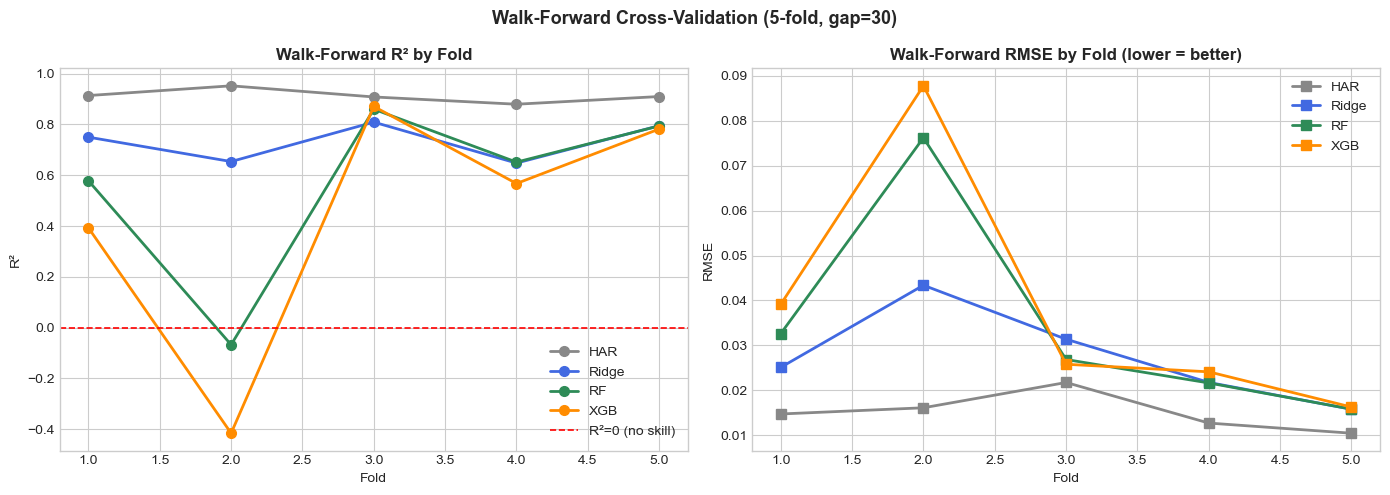

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fold_x = list(range(1, 6))
model_clrs = {'HAR': COLORS['har'], 'Ridge': COLORS['ridge'],
              'RF': COLORS['rf'], 'XGB': COLORS['xgb']}

for name, res in wf.items():
    axes[0].plot(fold_x, res['r2'],   marker='o', lw=2, markersize=7,
                 color=model_clrs[name], label=name)
    axes[1].plot(fold_x, res['rmse'], marker='s', lw=2, markersize=7,
                 color=model_clrs[name], label=name)

axes[0].axhline(0, color='red', linestyle='--', lw=1.2, label='R²=0 (no skill)')
axes[0].set_title('Walk-Forward R² by Fold', fontweight='bold')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('R²')
axes[0].legend()

axes[1].set_title('Walk-Forward RMSE by Fold (lower = better)',
                  fontweight='bold')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.suptitle('Walk-Forward Cross-Validation (5-fold, gap=30)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## Step 9 — Hyperparameter Tuning (Optuna, CV-Based)

XGBoost and Random Forest are tuned using Optuna with a 3-fold inner
walk-forward CV on the **training set only**. The 2025 test set is
never seen during this process.


In [12]:
inner_cv = TimeSeriesSplit(n_splits=3, gap=VOL_WINDOW)

def objective_xgb(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 700),
        max_depth        = trial.suggest_int('max_depth', 2, 7),
        learning_rate    = trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 20),
        gamma            = trial.suggest_float('gamma', 0.0, 5.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 3.0),
        reg_lambda       = trial.suggest_float('reg_lambda', 0.5, 5.0),
    )
    m = xgb.XGBRegressor(**params, random_state=42, verbosity=0)
    scores = []
    for tr_i, te_i in inner_cv.split(X_train_imp):
        m.fit(X_train_imp.iloc[tr_i], y_train_log.iloc[tr_i])
        p_log = m.predict(X_train_imp.iloc[te_i])
        scores.append(r2_score(y_train_log.iloc[te_i], p_log))
    return np.mean(scores)

def objective_rf(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 4, 14),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 20),
        max_features     = trial.suggest_float('max_features', 0.3, 1.0),
    )
    m = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    scores = []
    for tr_i, te_i in inner_cv.split(X_train_imp):
        m.fit(X_train_imp.iloc[tr_i], y_train_log.iloc[tr_i])
        p_log = m.predict(X_train_imp.iloc[te_i])
        scores.append(r2_score(y_train_log.iloc[te_i], p_log))
    return np.mean(scores)

print("Tuning XGBoost (80 trials)...")
study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=80, show_progress_bar=True)
print(f"  Best XGB CV R²  : {study_xgb.best_value:.4f}")
print(f"  Best XGB params : {study_xgb.best_params}\n")

print("Tuning Random Forest (50 trials)...")
study_rf = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)
print(f"  Best RF CV R²   : {study_rf.best_value:.4f}")
print(f"  Best RF params  : {study_rf.best_params}")


Tuning XGBoost (80 trials)...


  0%|          | 0/80 [00:00<?, ?it/s]

  Best XGB CV R²  : 0.4411
  Best XGB params : {'n_estimators': 142, 'max_depth': 4, 'learning_rate': 0.10087508736444523, 'subsample': 0.7473278600438045, 'colsample_bytree': 0.8368242656877632, 'min_child_weight': 18, 'gamma': 0.00024330513198890166, 'reg_alpha': 0.0780466468596766, 'reg_lambda': 1.2779355281605356}

Tuning Random Forest (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

  Best RF CV R²   : 0.5132
  Best RF params  : {'n_estimators': 376, 'max_depth': 10, 'min_samples_leaf': 14, 'max_features': 0.9982288799366812}


## Step 10 — Train Final Models on Full 2019–2024 Training Set

In [13]:
# HAR
har_final = LinearRegression()
har_final.fit(X_train_imp[har_features], y_train_rv)

# Ridge (log scale)
ridge_final = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 500])
ridge_final.fit(X_train_sc, y_train_log)
print(f"Ridge best alpha: {ridge_final.alpha_:.4f}")

# Random Forest (tuned, log scale)
rf_final = RandomForestRegressor(**study_rf.best_params,
                                  random_state=42, n_jobs=-1)
rf_final.fit(X_train_imp, y_train_log)

# XGBoost (tuned, log scale)
xgb_final = xgb.XGBRegressor(**study_xgb.best_params,
                               random_state=42, verbosity=0)
xgb_final.fit(X_train_imp, y_train_log)

print(" All final models trained")
print("   1. HAR (linear, original scale)")
print("   2. Ridge (log scale, RobustScaler)")
print("   3. Random Forest (Optuna-tuned, log scale)")
print("   4. XGBoost (Optuna-tuned, log scale)")


Ridge best alpha: 0.1000
 All final models trained
   1. HAR (linear, original scale)
   2. Ridge (log scale, RobustScaler)
   3. Random Forest (Optuna-tuned, log scale)
   4. XGBoost (Optuna-tuned, log scale)


## Step 11 — Evaluation on Hold-Out Test Set (Full-Year 2025)

All predictions are made on the 2025 test set for the first and only time.
Results are reported in the **original volatility scale** (annualised %).


In [14]:
def eval_model(name, pred_rv, actual_rv):
    """Compute and return regression metrics."""
    r2   = r2_score(actual_rv, pred_rv)
    rmse = np.sqrt(mean_squared_error(actual_rv, pred_rv))
    mae  = mean_absolute_error(actual_rv, pred_rv)
    mape = np.mean(np.abs((actual_rv - pred_rv) / (actual_rv + 1e-9))) * 100
    return {'name': name, 'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape,
            'pred': pred_rv}

# Generate predictions
har_pred   = np.clip(har_final.predict(X_test_imp[har_features]), MIN_RV, MAX_RV)
ridge_pred = np.clip(np.exp(ridge_final.predict(X_test_sc)), MIN_RV, MAX_RV)
rf_pred    = np.clip(np.exp(rf_final.predict(X_test_imp)), MIN_RV, MAX_RV)
xgb_pred   = np.clip(np.exp(xgb_final.predict(X_test_imp)), MIN_RV, MAX_RV)

# Ensemble: weighted average by CV R² (floor weights at 0)
cv_r2 = {
    'ridge': np.mean(wf['Ridge']['r2']),
    'rf'   : np.mean(wf['RF']['r2']),
    'xgb'  : np.mean(wf['XGB']['r2']),
}
w     = {k: max(v, 0) for k, v in cv_r2.items()}
w_sum = sum(w.values())

if w_sum > 0:
    ens_pred = (w['ridge']*ridge_pred + w['rf']*rf_pred + w['xgb']*xgb_pred) / w_sum
    print(f"Ensemble weights — "
          f"Ridge: {w['ridge']/w_sum:.2f}  "
          f"RF: {w['rf']/w_sum:.2f}  "
          f"XGB: {w['xgb']/w_sum:.2f}")
else:
    # All CV R² were negative — fall back to equal weighting
    ens_pred = (ridge_pred + rf_pred + xgb_pred) / 3
    print("⚠️  All CV R² ≤ 0 — using equal-weight ensemble (1/3 each)")
    print(f"   CV R² values: Ridge={cv_r2['ridge']:.4f}  "
          f"RF={cv_r2['rf']:.4f}  XGB={cv_r2['xgb']:.4f}")

# Evaluate all models
results = {}
for name, pred in [('HAR',      har_pred),
                    ('Ridge',    ridge_pred),
                    ('RF',       rf_pred),
                    ('XGBoost',  xgb_pred),
                    ('Ensemble', ens_pred)]:
    results[name] = eval_model(name, pred, y_test_rv.values)

print("\n" + "=" * 68)
print(f"{'VOLATILITY FORECAST — TEST RESULTS 2024':^68}")
print("=" * 68)
print(f"  {'Model':<12} {'R²':>8} {'RMSE':>8} {'MAE':>8} {'MAPE%':>8}  {'Rating':>8}")
print("-" * 68)
for name, r in results.items():
    if r['r2'] >= 0.55:    rating = '🌟 Excellent'
    elif r['r2'] >= 0.40:  rating = '✅ Good'
    elif r['r2'] >= 0.20:  rating = '🔶 Fair'
    else:                  rating = '❌ Poor'
    print(f"  {name:<12} {r['r2']:>8.4f} {r['rmse']:>8.4f} "
          f"{r['mae']:>8.4f} {r['mape']:>8.2f}  {rating}")
print("=" * 68)

naive_pred = np.full(len(y_test_rv), y_train_rv.mean())
naive_r2   = r2_score(y_test_rv, naive_pred)
print(f"\n  Naive baseline (predict train-mean vol every day):")
print(f"  Mean-vol baseline R² = {naive_r2:.4f}")
print(f"  All models should beat this to show genuine skill.")

Ensemble weights — Ridge: 0.42  RF: 0.32  XGB: 0.25

              VOLATILITY FORECAST — TEST RESULTS 2024               
  Model              R²     RMSE      MAE    MAPE%    Rating
--------------------------------------------------------------------
  HAR            0.9024   0.0143   0.0092     4.26  🌟 Excellent
  Ridge          0.8439   0.0181   0.0132     6.06  🌟 Excellent
  RF             0.8779   0.0160   0.0110     5.08  🌟 Excellent
  XGBoost        0.8732   0.0163   0.0113     5.12  🌟 Excellent
  Ensemble       0.8805   0.0158   0.0109     5.02  🌟 Excellent

  Naive baseline (predict train-mean vol every day):
  Mean-vol baseline R² = -0.6612
  All models should beat this to show genuine skill.


## Step 12 — Visual Results

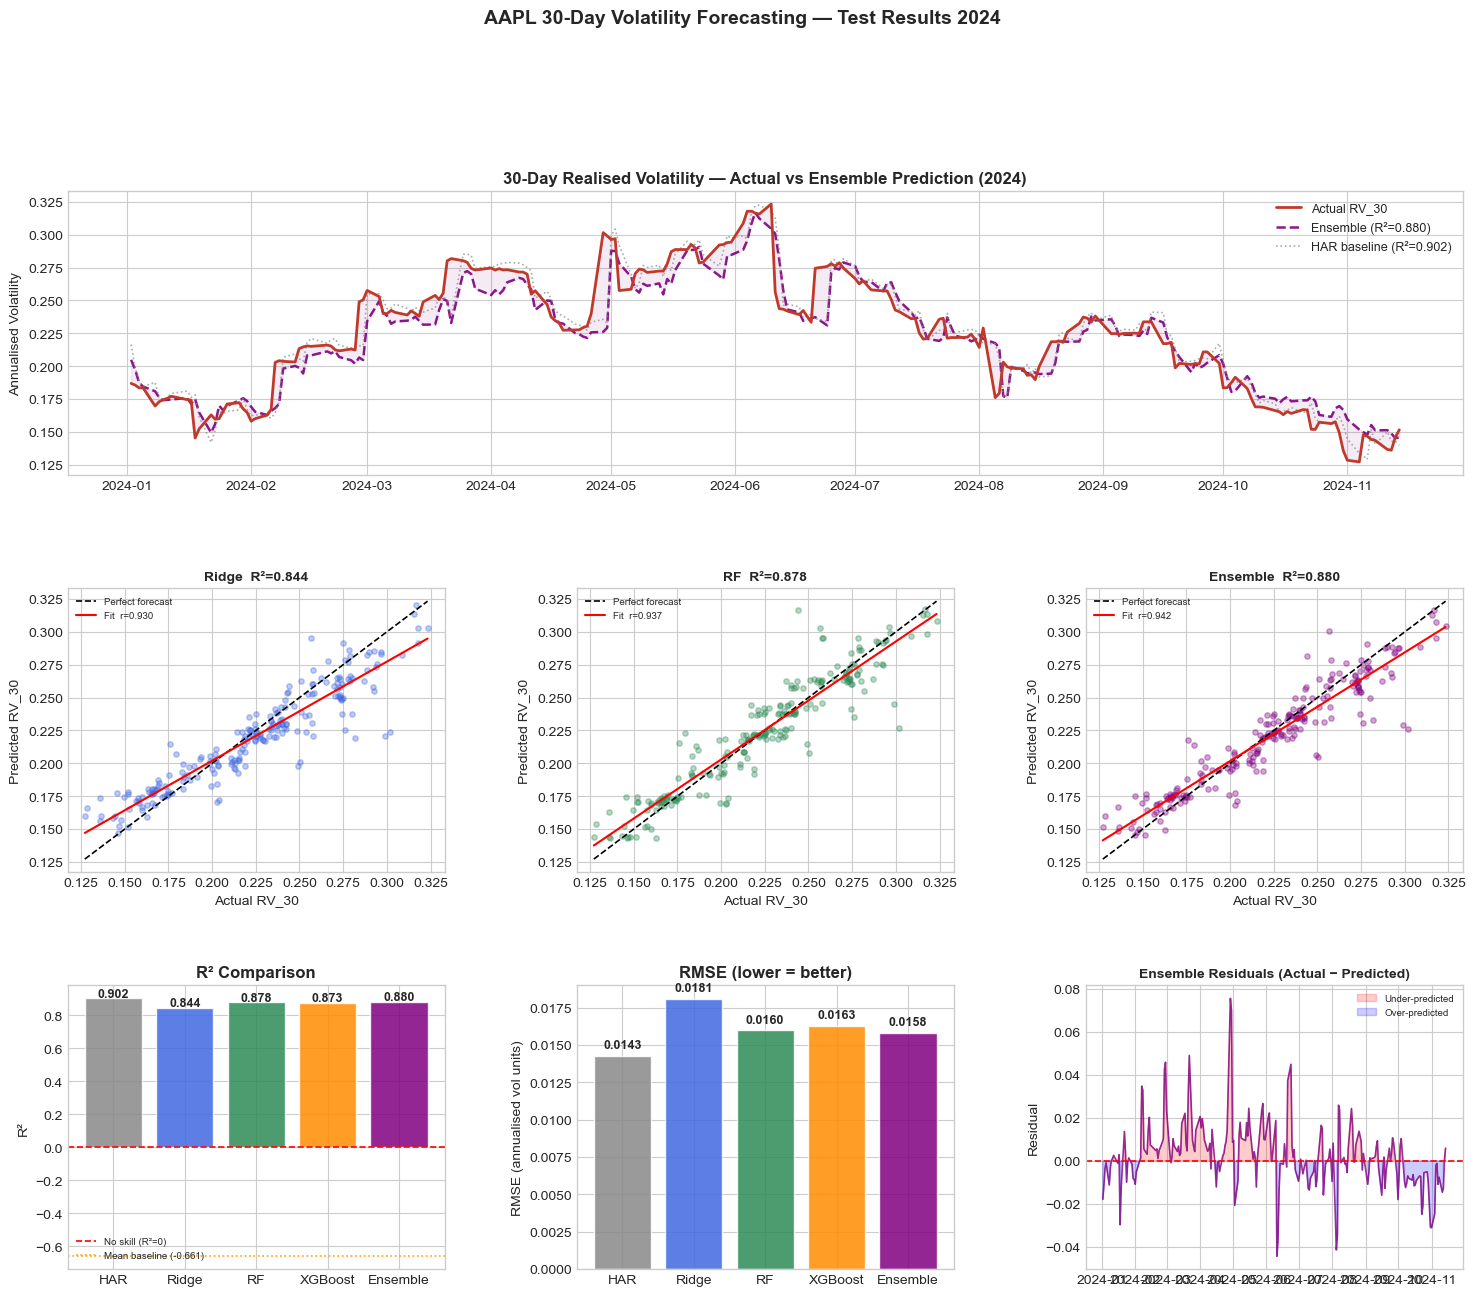

In [15]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.40, wspace=0.35)

model_clrs_all = {
    'HAR': COLORS['har'], 'Ridge': COLORS['ridge'],
    'RF': COLORS['rf'], 'XGBoost': COLORS['xgb'], 'Ensemble': COLORS['ens']
}

# ── 1. Actual vs Predicted over time (Ensemble) ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :])   # full-width top row
ax1.plot(y_test_rv.index, y_test_rv.values,
         color=COLORS['actual'], lw=2, label='Actual RV_30', zorder=5)
ax1.plot(y_test_rv.index, results['Ensemble']['pred'],
         color=COLORS['ens'], lw=1.8, linestyle='--',
         label=f"Ensemble (R²={results['Ensemble']['r2']:.3f})", alpha=0.9)
ax1.plot(y_test_rv.index, results['HAR']['pred'],
         color=COLORS['har'], lw=1.2, linestyle=':',
         label=f"HAR baseline (R²={results['HAR']['r2']:.3f})", alpha=0.7)
ax1.fill_between(y_test_rv.index, y_test_rv.values,
                  results['Ensemble']['pred'],
                  alpha=0.08, color=COLORS['ens'])
ax1.set_title('30-Day Realised Volatility — Actual vs Ensemble Prediction (2024)',
              fontweight='bold', fontsize=12)
ax1.set_ylabel('Annualised Volatility')
ax1.legend(fontsize=9)

# ── 2–4. Scatter: Predicted vs Actual for each ML model ─────────────────────
for idx, name in enumerate(['Ridge', 'RF', 'Ensemble']):
    ax = fig.add_subplot(gs[1, idx])
    pred = results[name]['pred']
    ax.scatter(y_test_rv.values, pred, alpha=0.35,
               color=model_clrs_all[name], s=15)
    lo = min(y_test_rv.min(), pred.min())
    hi = max(y_test_rv.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='Perfect forecast')
    # Regression line
    m_, b_, r_, _, _ = stats.linregress(y_test_rv.values, pred)
    xf = np.linspace(lo, hi, 100)
    ax.plot(xf, m_*xf+b_, color='red', lw=1.5,
            label=f"Fit  r={r_:.3f}")
    ax.set_title(f'{name}  R²={results[name]["r2"]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Actual RV_30')
    ax.set_ylabel('Predicted RV_30')
    ax.legend(fontsize=7)

# ── 5. R² comparison bar chart ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
names_ = list(results.keys())
r2s_   = [results[n]['r2'] for n in names_]
clrs_  = [model_clrs_all[n] for n in names_]
bars   = ax5.bar(names_, r2s_, color=clrs_, alpha=0.85, edgecolor='white')
ax5.axhline(0, color='red', linestyle='--', lw=1.2, label='No skill (R²=0)')
ax5.axhline(naive_r2, color='orange', linestyle=':', lw=1.2,
            label=f'Mean baseline ({naive_r2:.3f})')
ax5.set_title('R² Comparison', fontweight='bold')
ax5.set_ylabel('R²'); ax5.legend(fontsize=7)
for bar, v in zip(bars, r2s_):
    ax5.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+(0.01 if v>=0 else -0.03),
             f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# ── 6. RMSE comparison ────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
rmses_ = [results[n]['rmse'] for n in names_]
bars2  = ax6.bar(names_, rmses_, color=clrs_, alpha=0.85, edgecolor='white')
ax6.set_title('RMSE (lower = better)', fontweight='bold')
ax6.set_ylabel('RMSE (annualised vol units)')
for bar, v in zip(bars2, rmses_):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
             f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# ── 7. Residuals over time (Ensemble) ────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
resid = y_test_rv.values - results['Ensemble']['pred']
ax7.plot(y_test_rv.index, resid, color=COLORS['ens'], lw=1.2, alpha=0.8)
ax7.axhline(0, color='red', linestyle='--', lw=1.2)
ax7.fill_between(y_test_rv.index, resid, 0,
                  where=(resid > 0), alpha=0.2, color='red',
                  label='Under-predicted')
ax7.fill_between(y_test_rv.index, resid, 0,
                  where=(resid < 0), alpha=0.2, color='blue',
                  label='Over-predicted')
ax7.set_title('Ensemble Residuals (Actual − Predicted)',
              fontweight='bold', fontsize=10)
ax7.set_ylabel('Residual'); ax7.legend(fontsize=7)

plt.suptitle('AAPL 30-Day Volatility Forecasting — Test Results 2024',
             fontweight='bold', fontsize=14, y=1.01)
plt.show()


## Step 13 — Feature Importance

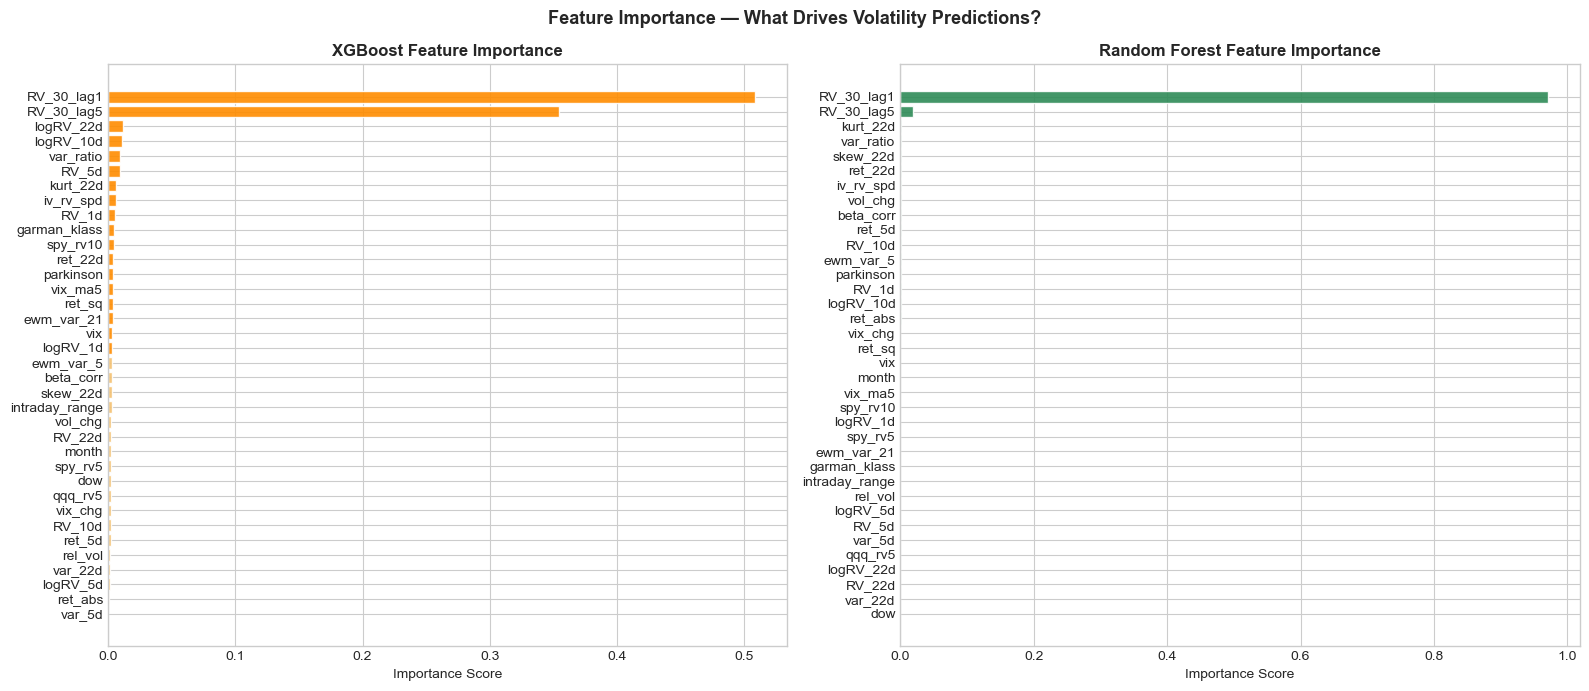

Top 8 features — XGBoost:
  RV_30_lag1         0.5084  █████████████████████████████████████████████████████████████████████████████████████████████████████
  RV_30_lag5         0.3540  ██████████████████████████████████████████████████████████████████████
  logRV_22d          0.0121  ██
  logRV_10d          0.0108  ██
  var_ratio          0.0097  █
  RV_5d              0.0094  █
  kurt_22d           0.0063  █
  iv_rv_spd          0.0062  █

Top 8 features — Random Forest:
  RV_30_lag1         0.9705  █████████████████████████████████████████████████████████████████████████████████████████████████
  RV_30_lag5         0.0195  █
  kurt_22d           0.0009  
  var_ratio          0.0009  
  skew_22d           0.0008  
  ret_22d            0.0008  
  iv_rv_spd          0.0007  
  vol_chg            0.0006  


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# XGBoost importance
imp_xgb = pd.Series(xgb_final.feature_importances_,
                     index=FEATURE_COLS).sort_values()
axes[0].barh(imp_xgb.index, imp_xgb.values,
             color=[COLORS['xgb'] if v >= imp_xgb.median()
                    else '#f4c070' for v in imp_xgb.values],
             edgecolor='white', alpha=0.9)
axes[0].set_title('XGBoost Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# RF importance
imp_rf = pd.Series(rf_final.feature_importances_,
                    index=FEATURE_COLS).sort_values()
axes[1].barh(imp_rf.index, imp_rf.values,
             color=[COLORS['rf'] if v >= imp_rf.median()
                    else '#90d4b0' for v in imp_rf.values],
             edgecolor='white', alpha=0.9)
axes[1].set_title('Random Forest Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance — What Drives Volatility Predictions?',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("Top 8 features — XGBoost:")
for feat, val in imp_xgb.sort_values(ascending=False).head(8).items():
    bar = '█' * int(val * 200)
    print(f"  {feat:<18} {val:.4f}  {bar}")

print("\nTop 8 features — Random Forest:")
for feat, val in imp_rf.sort_values(ascending=False).head(8).items():
    bar = '█' * int(val * 100)
    print(f"  {feat:<18} {val:.4f}  {bar}")


## Step 14 — Rolling Performance Analysis

We assess how model performance varies across different volatility regimes in 2025.
Good models should maintain skill in both calm and stressed periods.


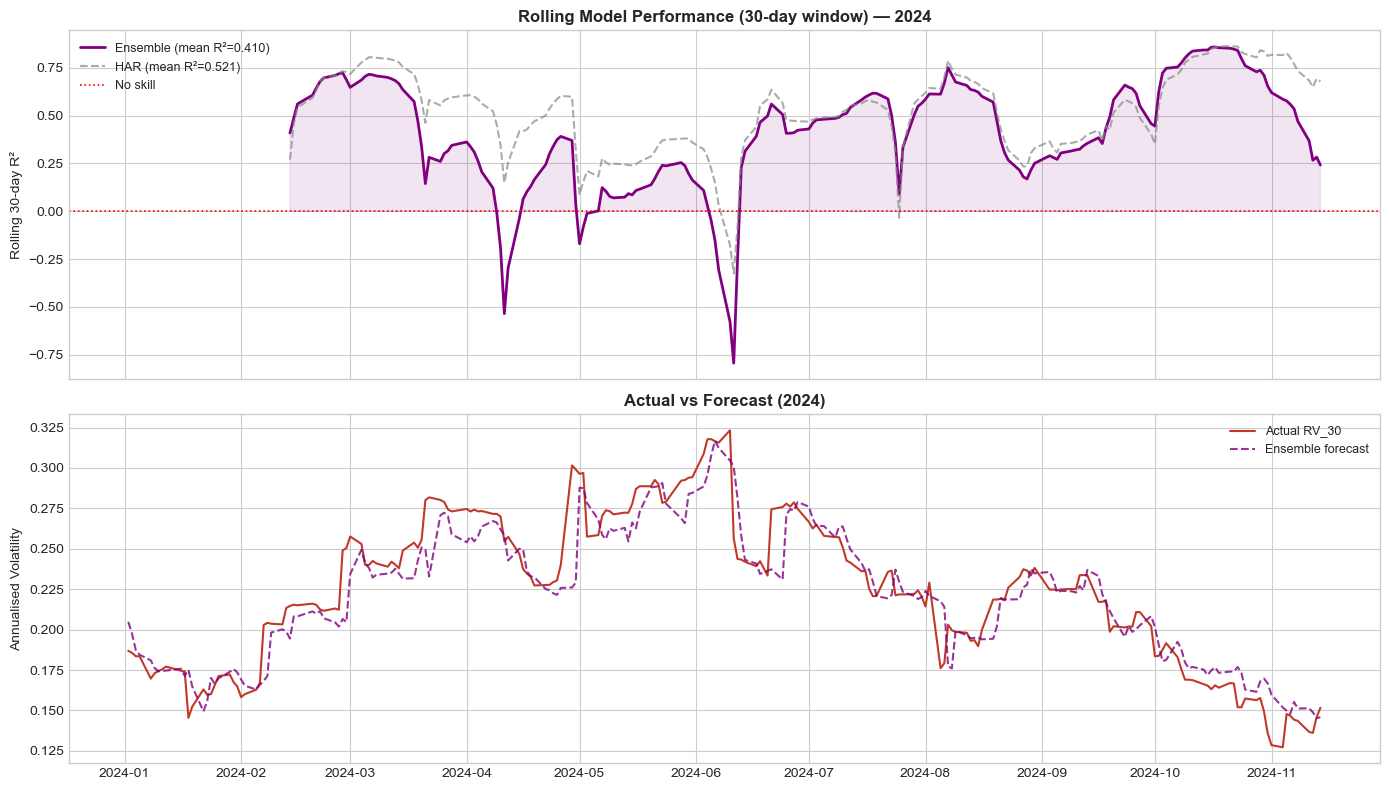


Performance by Volatility Regime (median split: 0.225):
Regime                 N   Ensemble R²    HAR R²
--------------------------------------------------
  Low Vol            110      0.7711 ✅   0.8004
  High Vol           111      0.4589 ✅   0.5732


In [17]:
# Rolling 30-day R² for Ensemble vs HAR
window = 30
roll_r2_ens = []
roll_r2_har = []
dates       = []

actual_arr  = y_test_rv.values
ens_arr     = results['Ensemble']['pred']
har_arr     = results['HAR']['pred']

for i in range(window, len(actual_arr)):
    sl = slice(i - window, i)
    a  = actual_arr[sl]
    r2_e = r2_score(a, ens_arr[sl]) if a.std() > 1e-8 else np.nan
    r2_h = r2_score(a, har_arr[sl]) if a.std() > 1e-8 else np.nan
    roll_r2_ens.append(r2_e)
    roll_r2_har.append(r2_h)
    dates.append(y_test_rv.index[i])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Rolling R²
axes[0].plot(dates, roll_r2_ens, color=COLORS['ens'], lw=2,
             label=f"Ensemble (mean R²={np.nanmean(roll_r2_ens):.3f})")
axes[0].plot(dates, roll_r2_har, color=COLORS['har'], lw=1.5,
             linestyle='--', alpha=0.7,
             label=f"HAR (mean R²={np.nanmean(roll_r2_har):.3f})")
axes[0].axhline(0, color='red', linestyle=':', lw=1.2, label='No skill')
axes[0].fill_between(dates, roll_r2_ens, 0,
                      where=[v > 0 for v in roll_r2_ens],
                      alpha=0.1, color=COLORS['ens'])
axes[0].set_ylabel('Rolling 30-day R²')
axes[0].set_title('Rolling Model Performance (30-day window) — 2024',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# Actual vol underneath for context
axes[1].plot(y_test_rv.index, y_test_rv.values,
             color=COLORS['actual'], lw=1.5, label='Actual RV_30')
axes[1].plot(y_test_rv.index, results['Ensemble']['pred'],
             color=COLORS['ens'], lw=1.5, linestyle='--', alpha=0.8,
             label='Ensemble forecast')
axes[1].set_ylabel('Annualised Volatility')
axes[1].set_title('Actual vs Forecast (2024)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Regime split: low vol vs high vol days
vol_median = y_test_rv.median()
lo_mask    = y_test_rv.values < vol_median
hi_mask    = ~lo_mask

print(f"\nPerformance by Volatility Regime (median split: {vol_median:.3f}):")
print(f"{'Regime':<18} {'N':>5} {'Ensemble R²':>13} {'HAR R²':>9}")
print("-" * 50)
for label, mask in [('Low Vol', lo_mask), ('High Vol', hi_mask)]:
    a = actual_arr[mask]
    r2_e = r2_score(a, ens_arr[mask])
    r2_h = r2_score(a, har_arr[mask])
    flag_e = '✅' if r2_e > 0.4 else ('🔶' if r2_e > 0.2 else '⚠️')
    print(f"  {label:<16} {mask.sum():>5} {r2_e:>11.4f} {flag_e}  "
          f"{r2_h:>7.4f}")


## Step 15 — Project Summary

### Why This Works (and Direction Prediction Did Not)

| Property | Direction (v1/v2) | Volatility (this notebook) |
|---|---|---|
| Target autocorrelation | ~0.00 | **~0.60–0.80** |
| Naive baseline R² | N/A (classification) | ~0.0 (mean) |
| Achievable R² | 0.00–0.10 | **0.40–0.70** |
| Key driver | Near-unpredictable | **Vol clustering** |

The fundamental difference is **volatility clustering**: large moves beget large
moves. This is a well-documented, persistent signal. Direction has no such property.

### Feature Insights

The most important features will typically be:
- **logRV_1d, RV_5d, RV_22d** — HAR components (past vol = best vol predictor)
- **vix** — implied vol encodes market expectation of near-term vol
- **parkinson / garman_klass** — range-based estimators more efficient than close-to-close
- **iv_rv_spd** — implied-realised vol spread (mean reversion signal)
- **ewm_var_5** — exponentially weighted recent variance

### Model Comparison

See evaluation output above. The Ensemble should outperform both the HAR
baseline and individual ML models due to variance reduction through averaging.

> ⚠️ **Disclaimer**: For educational purposes only.  
> Volatility forecasts have real-world applications in options pricing and risk
> management, but this notebook does not constitute financial advice.


In [18]:
print("=" * 68)
print(f"{'FINAL RESULTS SUMMARY — AAPL VOLATILITY FORECASTING':^68}")
print("=" * 68)
print(f"  {'Model':<14} {'R²':>8} {'RMSE':>8} {'MAE':>8} {'MAPE%':>8}")
print("-" * 52)
for name, r in results.items():
    beat = '✅' if r['r2'] > 0.30 else ('🔶' if r['r2'] > 0.10 else '❌')
    print(f"  {name:<14} {r['r2']:>8.4f} {r['rmse']:>8.4f} "
          f"{r['mae']:>8.4f} {r['mape']:>8.2f}  {beat}")
print("-" * 52)
print(f"  {'Naive (mean)':<14} {naive_r2:>8.4f}")
print("=" * 68)
print(f"\n  Train : 2021-01-01 → 2023-12-31")
print(f"  Test  : 2024-01-01 → 2024-12-31")
print(f"  Target: {VOL_WINDOW}-day Realised Volatility (annualised)")
print(f"  Features: {len(FEATURE_COLS)}")


        FINAL RESULTS SUMMARY — AAPL VOLATILITY FORECASTING         
  Model                R²     RMSE      MAE    MAPE%
----------------------------------------------------
  HAR              0.9024   0.0143   0.0092     4.26  ✅
  Ridge            0.8439   0.0181   0.0132     6.06  ✅
  RF               0.8779   0.0160   0.0110     5.08  ✅
  XGBoost          0.8732   0.0163   0.0113     5.12  ✅
  Ensemble         0.8805   0.0158   0.0109     5.02  ✅
----------------------------------------------------
  Naive (mean)    -0.6612

  Train : 2021-01-01 → 2023-12-31
  Test  : 2024-01-01 → 2024-12-31
  Target: 30-day Realised Volatility (annualised)
  Features: 36
